### <font color='blue'>Statistical Modeling of Socioeconomic Indicators</font>

## Data Source

**Source:** World Health Organization (WHO) – Global Health Observatory (GHO)  
**Dataset:** Life Expectancy and Healthy Life Expectancy (HALE)  
**Provider:** World Health Organization (WHO)  
**Access:** WHO Global Health Observatory

[WHO – Life Expectancy and Healthy Life Expectancy](https://www.who.int/data/gho/data/themes/mortality-and-global-health-estimates/ghe-life-expectancy-and-healthy-life-expectancy)

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import StandardScaler 
import warnings
warnings.filterwarnings("ignore")

## Loading and Understanding the Data

In [2]:
# Load the dataset
df_original = pd.read_csv('dataset.csv')

df = df_original.copy()

In [3]:
# Shape
df.shape

(2938, 22)

In [4]:
# Type data
df.dtypes

Country                                str
Year                                 int64
Status                                 str
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
 Population                        float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [5]:
# Sample
df.sample(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1655,Mauritania,2011,Developing,62.2,212.0,8,0.01,79.276585,75.0,234,...,73.0,2.87,75.0,1.2,1393.261593,3.717672e+06,8.5,8.3,0.487,7.7
363,Brazil,2004,Developing,72.0,17.0,81,6.85,186.609049,96.0,0,...,99.0,7.70,99.0,0.1,3623.476670,1.847385e+08,3.2,3.2,0.695,14.0
1187,India,2014,Developing,68.0,184.0,957,3.07,86.521539,79.0,79563,...,84.0,4.69,85.0,0.2,1573.118890,1.293859e+09,26.8,27.4,0.607,11.6
2685,Turkey,2011,Developing,74.5,114.0,20,1.53,1275.877569,96.0,111,...,97.0,5.29,97.0,0.1,11341.133950,7.349455e+06,4.9,4.7,0.737,13.8
1948,Pakistan,2009,Developing,64.8,175.0,371,0.03,0.697216,78.0,863,...,7.0,2.94,71.0,0.1,16.639990,1.674958e+06,2.5,2.9,0.514,7.3
1247,Iraq,2002,Developing,74.0,14.0,30,0.15,0.000000,65.0,0,...,76.0,NaN,77.0,0.1,NaN,2.493930e+07,5.5,5.3,0.614,9.1
2874,Viet Nam,2015,Developing,76.0,127.0,28,NaN,0.000000,97.0,256,...,97.0,NaN,97.0,0.1,NaN,NaN,14.2,14.5,0.678,12.6
2421,South Sudan,2003,Developing,58.0,383.0,29,NaN,0.000000,NaN,0,...,NaN,NaN,NaN,3.5,NaN,7.516420e+05,NaN,NaN,0.000,0.0
1637,Malta,2012,Developed,81.0,58.0,0,7.67,343.123395,93.0,0,...,99.0,9.95,99.0,0.1,2193.883600,4.194550e+05,0.8,0.7,0.821,14.1
715,Democratic People's Republic of Korea,2005,Developing,68.5,165.0,10,3.21,0.000000,92.0,0,...,97.0,NaN,79.0,0.1,NaN,NaN,5.7,5.7,NaN,NaN


## Initial Data Preparation

In [6]:
# Columns
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', ' Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')

In [7]:
# Fixing tha names columns, removing spacing and changing to lower case
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under-five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv/aids', 'gdp', 'population', 'thinness__1-19_years',
       'thinness_5-9_years', 'income_composition_of_resources', 'schooling'],
      dtype='str')

In [8]:
# Removing columns without documented descriptions in the original data source.
columns_to_remove = ["percentage_expenditure", "under-five_deaths", "income_composition_of_resources"]

df.drop(columns=columns_to_remove, inplace=True)

df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'hepatitis_b', 'measles', 'bmi', 'polio',
       'total_expenditure', 'diphtheria', 'hiv/aids', 'gdp', 'population',
       'thinness__1-19_years', 'thinness_5-9_years', 'schooling'],
      dtype='str')

In [9]:
df.columns = ['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'hepatitis_b', 'measles', 'bmi', 'polio',
       'total_expenditure', 'diphtheria', 'hiv', 'gdp', 'population',
       'thinness_till19', 'thinness_till9', 'schooling']

In [10]:
# Types data
df.dtypes

country                  str
year                   int64
status                   str
life_expectancy      float64
adult_mortality      float64
infant_deaths          int64
alcohol              float64
hepatitis_b          float64
measles                int64
bmi                  float64
polio                float64
total_expenditure    float64
diphtheria           float64
hiv                  float64
gdp                  float64
population           float64
thinness_till19      float64
thinness_till9       float64
schooling            float64
dtype: object

In [11]:
# Shape
df.shape

(2938, 19)

In [12]:
# Dataset
df.head()

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,65.0,1154,19.1,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,62.0,492,18.6,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,64.0,430,18.1,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,67.0,2787,17.6,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,68.0,3013,17.2,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,9.5


## Exploratory Data Analysis

In [13]:
# Creates a dictionary containing the description of each variable
df_dict = {
    "country": "Country where the data was collected.",
    "life_expectancy": "Life expectancy at birth, in years.",
    "year": "Year in which the data was collected.",
    "status": "Development status of the country ('Developing' or 'Developed').",
    "adult_mortality": "Adult mortality rate between ages 15 and 60 per 1,000 population.",
    "infant_deaths": "Number of deaths of children under 5 years of age per 1,000 live births.",
    "alcohol": "Alcohol consumption per capita (liters of pure alcohol per year).",
    "hepatitis_b": "Hepatitis B vaccination coverage among 1-year-old children (%).",
    "measles": "Number of reported measles cases per 1,000 population.",
    "bmi": "Average Body Mass Index (BMI) of the adult population.",
    "polio": "Polio vaccination coverage among 1-year-old children (%).",
    "diphtheria": "Diphtheria, tetanus, and pertussis (DTP3) vaccination coverage among 1-year-old children (%).",
    "hiv": "HIV prevalence among the adult population (%).",
    "gdp": "Gross Domestic Product (GDP) per capita, in US dollars.",
    "total_expenditure": "Total health expenditure as a percentage of GDP.",
    "thinness_till19": "Prevalence of thinness among children and adolescents aged 10 to 19 (%).",
    "thinness_till9": "Prevalence of thinness among children aged 5 to 9 (%).",
    "schooling": "Average number of years of schooling.",
    "population": "Total population of the country."
}

In [14]:
# If we need to check the meaning of a variable, we can look it up directly in the dictionary created above.
df_dict["life_expectancy"]

'Life expectancy at birth, in years.'

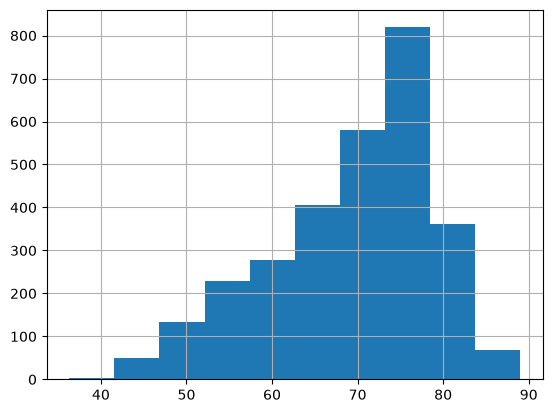

In [15]:
# Plotting the histogram of the target variable (quantitative variable)
df["life_expectancy"].hist();

In [16]:
# Statistical summary (numerical variables)
df.describe()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2385.000000,2938.000000,2904.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,80.940461,2419.592240,38.321247,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,25.070016,11467.272489,20.044034,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,1.000000,0.000000,1.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,77.000000,0.000000,19.300000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,92.000000,17.000000,43.500000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,97.000000,360.250000,56.200000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,99.000000,212183.000000,87.300000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,20.700000


In [17]:
# Statistical summary (categorical variables)
df.describe(include=['object'])

,country,status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


In [18]:
# Function to plot the relationship between the target variable and selected features

def get_pairs(data, target, features, n):

    # Groups the features into sets of n plots per row
    row_groups = [features[i:i+n] for i in range(0, len(features), n)]

    # Loops through each group to create the pair plots
    for row in row_groups:

        plot = sns.pairplot(
                                x_vars=row,
                                y_vars=target,
                                data=data,
                                kind="reg",
                                height=3
                            )

    return

In [19]:
# Target variable
target = ["life_expectancy"]

In [20]:
# Using some features
features = ["population", "hepatitis_b", "gdp", "total_expenditure", "alcohol", "schooling"]

In [21]:
# Description about the features variables
for f in features:
    print(f"{f}: {df_dict[f]}")

population: Total population of the country.
hepatitis_b: Hepatitis B vaccination coverage among 1-year-old children (%).
gdp: Gross Domestic Product (GDP) per capita, in US dollars.
total_expenditure: Total health expenditure as a percentage of GDP.
alcohol: Alcohol consumption per capita (liters of pure alcohol per year).
schooling: Average number of years of schooling.


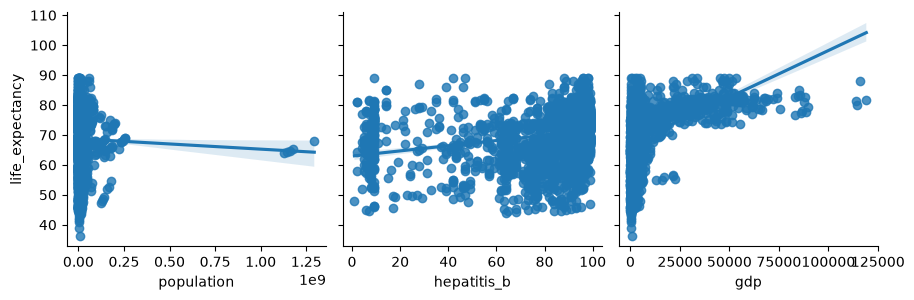

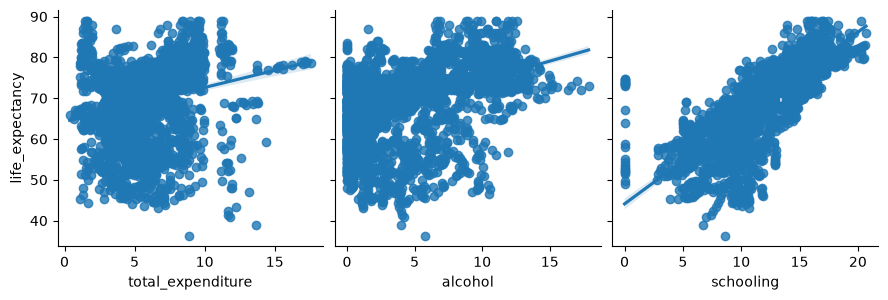

In [22]:
# Checking the outliers in the features variables
get_pairs(data=df, target=target, features=features, n=3)

## Detecting Missing Values

In [23]:
# Displaying the total number of non-null rows in each column
df.count()

country              2938
year                 2938
status               2938
life_expectancy      2928
adult_mortality      2928
infant_deaths        2938
alcohol              2744
hepatitis_b          2385
measles              2938
bmi                  2904
polio                2919
total_expenditure    2712
diphtheria           2919
hiv                  2938
gdp                  2490
population           2286
thinness_till19      2904
thinness_till9       2904
schooling            2775
dtype: int64

In [24]:
# Extracting the total number of missing values per column
missing_values = df.isnull().sum().sort_values(ascending=False)

print(missing_values)

population           652
hepatitis_b          553
gdp                  448
total_expenditure    226
alcohol              194
schooling            163
bmi                   34
thinness_till9        34
thinness_till19       34
diphtheria            19
polio                 19
adult_mortality       10
life_expectancy       10
country                0
year                   0
status                 0
infant_deaths          0
measles                0
hiv                    0
dtype: int64


In [25]:
# Calculating the percentage of missing values
missing_values_percent = missing_values[missing_values > 0] / df.shape[0]

print(f'{round(missing_values_percent * 100, 2)}')

population           22.19
hepatitis_b          18.82
gdp                  15.25
total_expenditure     7.69
alcohol               6.60
schooling             5.55
bmi                   1.16
thinness_till9        1.16
thinness_till19       1.16
diphtheria            0.65
polio                 0.65
adult_mortality       0.34
life_expectancy       0.34
dtype: float64


## Checking Outliers

In [26]:
# Features with more than 5% of missing values
features_with_missing_values = list(missing_values_percent[missing_values_percent > 0.05].index)
print(features_with_missing_values)

['population', 'hepatitis_b', 'gdp', 'total_expenditure', 'alcohol', 'schooling']


In [27]:
# Creating a new dataframe
new_df = df[features_with_missing_values].copy()

new_df

,population,hepatitis_b,gdp,total_expenditure,alcohol,schooling
0,33736494.0,65.0,584.259210,8.16,0.01,10.1
1,327582.0,62.0,612.696514,8.18,0.01,10.0
2,31731688.0,64.0,631.744976,8.13,0.01,9.9
3,3696958.0,67.0,669.959000,8.52,0.01,9.8
4,2978599.0,68.0,63.537231,7.87,0.01,9.5
...,...,...,...,...,...,...
2933,12777511.0,68.0,454.366654,7.13,4.36,9.2
2934,12633897.0,7.0,453.351155,6.52,4.06,9.5
2935,125525.0,73.0,57.348340,6.53,4.43,10.0
2936,12366165.0,76.0,548.587312,6.16,1.72,9.8


In [28]:
# Identifying outliers using the IQR (Interquartile Range) method
Q1 = new_df.quantile(0.25)
Q3 = new_df.quantile(0.75)
IQR = Q3 - Q1

In [29]:
# Defining outliers as values outside the range [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]
outliers = ((new_df < (Q1 - 1.5 * IQR)) | 
            (new_df > (Q3 + 1.5 * IQR))).sum()

outliers

population           294
hepatitis_b          254
gdp                  365
total_expenditure     32
alcohol                0
schooling             44
dtype: int64

In [30]:
# Creates a summary of the detected outliers
outliers_summary = pd.DataFrame({
    'Outliers': outliers,
    'Percentage': (outliers / len(new_df)) * 100
})

In [31]:
# Returns only the results where the number of outliers is greater than zero
outliers_summary[outliers_summary['Outliers'] > 0]

,Outliers,Percentage
population,294,10.006807
hepatitis_b,254,8.645337
gdp,365,12.423417
total_expenditure,32,1.089176
schooling,44,1.497617


## Statistical Analysis for Outlier Treatment

In [32]:
# Defining the lower and upper bounds for filtering outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [33]:
# Filtering out the outliers
new_df2 = df[
    ~((new_df < lower_bound) | 
      (new_df > upper_bound)).any(axis=1)
]

new_df2

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,62.0,492,18.6,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,10.0
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,67.0,2787,17.6,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,68.0,3013,17.2,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,66.0,1989,16.7,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,63.0,2861,16.2,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,8.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2932,Zimbabwe,2005,Developing,44.6,717.0,28,4.14,65.0,420,27.5,69.0,6.44,68.0,30.3,444.765750,129432.0,9.0,9.0,9.3
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,68.0,31,27.1,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,9.2
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,73.0,304,26.3,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,76.0,529,25.9,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,9.8


### Important Considerations

- The **1.5 × IQR rule** is a commonly used method for identifying outliers, but it should not be treated as a strict rule.
- The choice of the **1.5 multiplier** may vary depending on the context and characteristics of the dataset.
- It is important to **visually inspect the data distribution** to confirm the presence of potential outliers and adjust the thresholds if necessary.
- Other outlier detection techniques can be used alongside the **IQR method** to provide a more comprehensive analysis.

In [34]:
# shape
new_df2.shape

(2044, 19)

In [35]:
# Stastistical summary
new_df2.describe()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling
count,2044.000000,2036.000000,2036.000000,2044.000000,1908.000000,1653.000000,2044.000000,2032.000000,2041.000000,1883.000000,2041.000000,2044.000000,1668.000000,1.550000e+03,2032.000000,2032.000000,1910.000000
mean,2007.516634,68.261444,173.697937,21.272016,4.250854,88.543860,2043.051859,37.229429,83.469868,5.817047,84.229789,1.906115,2603.414714,2.862564e+06,4.973327,5.039813,11.779791
std,4.620838,9.180601,124.821601,75.877341,3.821064,11.667147,11166.996177,19.540099,22.293545,2.167468,20.802376,5.353430,3051.987902,4.147575e+06,4.070398,4.188165,2.893174
min,2000.000000,36.300000,1.000000,0.000000,0.010000,47.000000,0.000000,1.000000,3.000000,0.370000,3.000000,0.100000,3.685949,3.400000e+01,0.100000,0.100000,3.800000
25%,2003.000000,62.475000,83.750000,0.000000,0.847500,84.000000,0.000000,19.200000,78.000000,4.380000,81.000000,0.100000,387.645945,1.413295e+05,1.900000,1.900000,10.100000
50%,2008.000000,71.400000,154.000000,3.000000,3.400000,93.000000,10.000000,41.300000,93.000000,5.710000,93.000000,0.100000,1312.038142,8.968025e+05,3.550000,3.600000,12.100000
75%,2012.000000,74.700000,235.000000,17.000000,6.725000,97.000000,256.250000,54.900000,97.000000,7.130000,97.000000,1.000000,3936.450613,3.712494e+06,7.325000,7.400000,13.700000
max,2015.000000,89.000000,723.000000,1800.000000,17.310000,99.000000,212183.000000,87.300000,99.000000,12.250000,99.000000,50.300000,13893.187680,1.789956e+07,27.700000,28.600000,20.400000


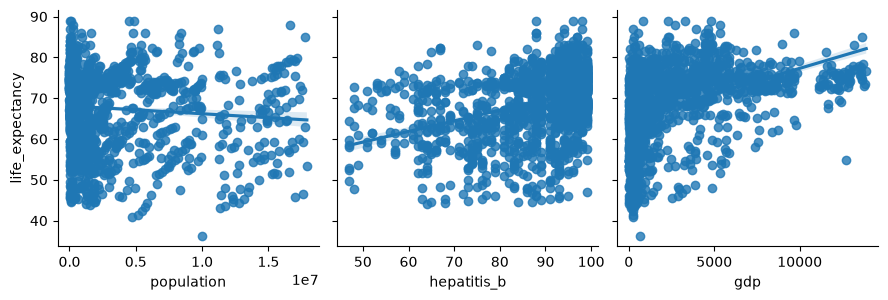

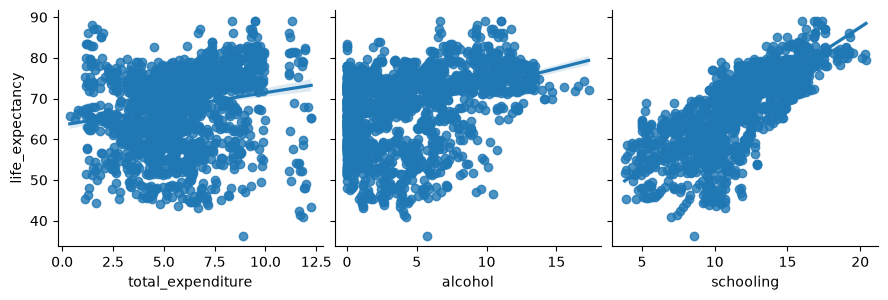

In [36]:
# Checking the outliers
get_pairs(data=new_df2, target=target, features=features, n=3)

## Statistical Analysis for Missing Value Treatment

In [37]:
# Checking the total number of missing values
missing_values = new_df2.isnull().sum().sort_values(ascending=False)

In [38]:
# Checking the percentage of missing values
missing_values_percent = missing_values[missing_values > 0] / new_df2.shape[0]

print(f'{round(missing_values_percent * 100, 2)} %')

population           24.17
hepatitis_b          19.13
gdp                  18.40
total_expenditure     7.88
alcohol               6.65
schooling             6.56
bmi                   0.59
thinness_till9        0.59
thinness_till19       0.59
adult_mortality       0.39
life_expectancy       0.39
diphtheria            0.15
polio                 0.15
dtype: float64 %


In [39]:
# Function to replace missing values with the median
def impute_median(data):
    
    return data.fillna(data.median())

In [40]:
# Stastistical summary
new_df2.describe()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling
count,2044.000000,2036.000000,2036.000000,2044.000000,1908.000000,1653.000000,2044.000000,2032.000000,2041.000000,1883.000000,2041.000000,2044.000000,1668.000000,1.550000e+03,2032.000000,2032.000000,1910.000000
mean,2007.516634,68.261444,173.697937,21.272016,4.250854,88.543860,2043.051859,37.229429,83.469868,5.817047,84.229789,1.906115,2603.414714,2.862564e+06,4.973327,5.039813,11.779791
std,4.620838,9.180601,124.821601,75.877341,3.821064,11.667147,11166.996177,19.540099,22.293545,2.167468,20.802376,5.353430,3051.987902,4.147575e+06,4.070398,4.188165,2.893174
min,2000.000000,36.300000,1.000000,0.000000,0.010000,47.000000,0.000000,1.000000,3.000000,0.370000,3.000000,0.100000,3.685949,3.400000e+01,0.100000,0.100000,3.800000
25%,2003.000000,62.475000,83.750000,0.000000,0.847500,84.000000,0.000000,19.200000,78.000000,4.380000,81.000000,0.100000,387.645945,1.413295e+05,1.900000,1.900000,10.100000
50%,2008.000000,71.400000,154.000000,3.000000,3.400000,93.000000,10.000000,41.300000,93.000000,5.710000,93.000000,0.100000,1312.038142,8.968025e+05,3.550000,3.600000,12.100000
75%,2012.000000,74.700000,235.000000,17.000000,6.725000,97.000000,256.250000,54.900000,97.000000,7.130000,97.000000,1.000000,3936.450613,3.712494e+06,7.325000,7.400000,13.700000
max,2015.000000,89.000000,723.000000,1800.000000,17.310000,99.000000,212183.000000,87.300000,99.000000,12.250000,99.000000,50.300000,13893.187680,1.789956e+07,27.700000,28.600000,20.400000


In [41]:
# Replacing missing values with the median
new_df2.loc[:, 'population'] = new_df2['population'].transform(impute_median)
new_df2.loc[:, 'hepatitis_b'] = new_df2['hepatitis_b'].transform(impute_median)
new_df2.loc[:, 'alcohol'] = new_df2['alcohol'].transform(impute_median)
new_df2.loc[:, 'total_expenditure'] = new_df2['total_expenditure'].transform(impute_median)
new_df2.loc[:, 'gdp'] = new_df2['gdp'].transform(impute_median)
new_df2.loc[:, 'schooling'] = new_df2['schooling'].transform(impute_median)

In [42]:
# Checking the total number of missing values
missing_values = new_df2.isnull().sum().sort_values(ascending=False)

missing_values

thinness_till19      12
thinness_till9       12
bmi                  12
adult_mortality       8
life_expectancy       8
polio                 3
diphtheria            3
status                0
year                  0
country               0
alcohol               0
hepatitis_b           0
measles               0
infant_deaths         0
total_expenditure     0
gdp                   0
hiv                   0
population            0
schooling             0
dtype: int64

In [43]:
# Checking the percentage of missing values
missing_values_percent = missing_values[missing_values > 0] / new_df2.shape[0]
print(f'{round(missing_values_percent * 100, 2)} %')

thinness_till19    0.59
thinness_till9     0.59
bmi                0.59
adult_mortality    0.39
life_expectancy    0.39
polio              0.15
diphtheria         0.15
dtype: float64 %


In [44]:
# Removing records with missing values
new_df2.dropna(inplace=True)

In [45]:
# Checking the total number of missing values
missing_values = new_df2.isnull().sum().sort_values(ascending=False)

In [46]:
# Checking the percentage of missing values
missing_values_percent = missing_values[missing_values > 0] / new_df2.shape[0]

print(f'{round(missing_values_percent * 100, 2)} %')

Series([], dtype: float64) %


In [47]:
# Shape
new_df2.shape

(2023, 19)

In [48]:
new_df2.info()

<class 'pandas.DataFrame'>
Index: 2023 entries, 1 to 2937
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            2023 non-null   str    
 1   year               2023 non-null   int64  
 2   status             2023 non-null   str    
 3   life_expectancy    2023 non-null   float64
 4   adult_mortality    2023 non-null   float64
 5   infant_deaths      2023 non-null   int64  
 6   alcohol            2023 non-null   float64
 7   hepatitis_b        2023 non-null   float64
 8   measles            2023 non-null   int64  
 9   bmi                2023 non-null   float64
 10  polio              2023 non-null   float64
 11  total_expenditure  2023 non-null   float64
 12  diphtheria         2023 non-null   float64
 13  hiv                2023 non-null   float64
 14  gdp                2023 non-null   float64
 15  population         2023 non-null   float64
 16  thinness_till19    2023 non-null   float

Using socioeconomic indicators independently of country identification. Therefore, remove the categorical variables from the dataset.

In [49]:
# Shape of original dataset
df_original.shape

(2938, 22)

In [50]:
# Drop
new_df2.drop(['country', 'status'], axis = 1, inplace = True)

# Shape
new_df2.shape

(2023, 17)

## Feature Engineering

> Since there are significant differences in population size across countries, using the raw population variable may introduce bias into the analysis. Therefore, we will create a new variable and categorize countries into three population groups.

In [51]:
new_df2.head()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling
1,2014,59.9,271.0,64,0.01,62.0,492,18.6,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,10.0
3,2012,59.5,272.0,69,0.01,67.0,2787,17.6,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,9.8
4,2011,59.2,275.0,71,0.01,68.0,3013,17.2,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,9.5
5,2010,58.8,279.0,74,0.01,66.0,1989,16.7,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,9.2
6,2009,58.6,281.0,77,0.01,63.0,2861,16.2,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,8.9


In [52]:
# Min population
new_df2['population'].min()

np.float64(34.0)

In [53]:
# Max population
new_df2['population'].max()

np.float64(17899562.0)

In [54]:
# Defining cutoffs using two percentiles as reference points
cut_off = [new_df2["population"].quantile(0.33), new_df2["population"].quantile(0.67)]

cut_off

[np.float64(656519.86), np.float64(1365811.6)]

In [55]:
# Creating a new variable with all values equal to 1
new_df2['pop_size'] = 1

In [56]:
# Defining the range where the variable will be assigned the value 2
new_df2.loc[(new_df2['population'] < cut_off[1]) &
            (new_df2['population'] > cut_off[0]), 
            'pop_size'] = 2

In [57]:
# Defining the range where the variable will be assigned the value 3
new_df2.loc[new_df2['population'] >= cut_off[1], 'pop_size'] = 3

In [58]:
# Head
new_df2.head()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling,pop_size
1,2014,59.9,271.0,64,0.01,62.0,492,18.6,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,10.0,1
3,2012,59.5,272.0,69,0.01,67.0,2787,17.6,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,9.8,3
4,2011,59.2,275.0,71,0.01,68.0,3013,17.2,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,9.5,3
5,2010,58.8,279.0,74,0.01,66.0,1989,16.7,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,9.2,3
6,2009,58.6,281.0,77,0.01,63.0,2861,16.2,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,8.9,1


In [59]:
new_df2['pop_size'].value_counts()

pop_size
2    687
1    668
3    668
Name: count, dtype: int64

> The `alcohol` and `bmi` variables have a direct and natural relationship. Therefore, we will create a new variable called `life_style` by combining these two variables.

In [60]:
print(f"bmi: {df_dict['bmi']}")
print(f"alcohol: {df_dict['alcohol']}")

bmi: Average Body Mass Index (BMI) of the adult population.
alcohol: Alcohol consumption per capita (liters of pure alcohol per year).


In [61]:
# Creating the new variable 'life style' based on the 'bmi' and 'alcohol'
new_df2['life_style'] = new_df2['bmi'] * new_df2['alcohol']

In [62]:
new_df2.head()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling,pop_size,life_style
1,2014,59.9,271.0,64,0.01,62.0,492,18.6,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,10.0,1,0.186
3,2012,59.5,272.0,69,0.01,67.0,2787,17.6,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,9.8,3,0.176
4,2011,59.2,275.0,71,0.01,68.0,3013,17.2,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,9.5,3,0.172
5,2010,58.8,279.0,74,0.01,66.0,1989,16.7,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,9.2,3,0.167
6,2009,58.6,281.0,77,0.01,63.0,2861,16.2,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,8.9,1,0.162


In [63]:
new_df2['life_style'].describe()

count    2023.000000
mean      178.996408
std       209.416553
min         0.018000
25%        18.140500
50%        95.323000
75%       257.394000
max      1036.869000
Name: life_style, dtype: float64

In [64]:
# Check missing values
missing_values = new_df2.isnull().sum().sort_values(ascending=False)
missing_values

year                 0
life_expectancy      0
adult_mortality      0
infant_deaths        0
alcohol              0
hepatitis_b          0
measles              0
bmi                  0
polio                0
total_expenditure    0
diphtheria           0
hiv                  0
gdp                  0
population           0
thinness_till19      0
thinness_till9       0
schooling            0
pop_size             0
life_style           0
dtype: int64

In [65]:
new_df2.dtypes

year                   int64
life_expectancy      float64
adult_mortality      float64
infant_deaths          int64
alcohol              float64
hepatitis_b          float64
measles                int64
bmi                  float64
polio                float64
total_expenditure    float64
diphtheria           float64
hiv                  float64
gdp                  float64
population           float64
thinness_till19      float64
thinness_till9       float64
schooling            float64
pop_size               int64
life_style           float64
dtype: object

## Correlation Analysis to Check for Multicollinearity

We want the predictor variables to have a strong correlation with the target variable, but we do not want the predictor variables to be highly correlated with each other. When predictor variables are strongly correlated with one another, this is known as **multicollinearity**, which can violate one of the assumptions of regression analysis.

Correlation measures the relationship between variables. The correlation coefficient ranges from **-1 to +1**, where:

- **-1 indicates a strong negative correlation.**
- **+1 indicates a strong positive correlation.**
- **0 indicates no linear correlation.**

It is important to remember that **correlation does not imply causation**.

For example, ice cream consumption and the presence of sharks at beaches may both increase during the summer. These events may therefore be correlated, but this does not mean that increased ice cream consumption causes an increase in shark presence, or vice versa. Both may simply be influenced by another factor, such as warmer weather.

To determine whether one variable actually causes changes in another, a **causal analysis** would be required.

In [66]:
# Correlation of the numerical variables in the dataset
new_df2.corr()

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling,pop_size,life_style
year,1.000000,0.204556,-0.091760,-0.059838,-0.066639,-0.003178,-0.064347,0.096763,0.147489,0.070267,0.228939,-0.158820,0.170945,0.020981,-0.059353,-0.055950,0.219471,0.013190,-0.017373
life_expectancy,0.204556,1.000000,-0.658916,-0.206443,0.342425,0.257860,-0.115350,0.557954,0.452564,0.175738,0.483659,-0.573127,0.360736,-0.105317,-0.433580,-0.429357,0.708272,-0.117333,0.441366
adult_mortality,-0.091760,-0.658916,1.000000,0.099370,-0.149204,-0.188950,0.035432,-0.366745,-0.228938,-0.090963,-0.221803,0.512978,-0.197863,0.096768,0.299104,0.302507,-0.383901,0.123785,-0.231128
infant_deaths,-0.059838,-0.206443,0.099370,1.000000,-0.127545,-0.122515,0.480129,-0.221948,-0.183569,-0.121871,-0.183910,0.039115,-0.120331,0.111901,0.321487,0.354512,-0.214215,0.111776,-0.156769
alcohol,-0.066639,0.342425,-0.149204,-0.127545,1.000000,0.193844,-0.045324,0.310448,0.187916,0.262657,0.199958,-0.036268,0.289360,-0.007040,-0.386629,-0.379482,0.464657,0.002445,0.878858
hepatitis_b,-0.003178,0.257860,-0.188950,-0.122515,0.193844,1.000000,-0.043089,0.115409,0.393191,0.046093,0.391270,-0.090390,0.167829,-0.056455,-0.086406,-0.102546,0.263879,-0.028477,0.181579
measles,-0.064347,-0.115350,0.035432,0.480129,-0.045324,-0.043089,1.000000,-0.142187,-0.110853,-0.101675,-0.123043,0.024412,-0.065666,-0.005326,0.133515,0.137056,-0.089084,0.017013,-0.085123
bmi,0.096763,0.557954,-0.366745,-0.221948,0.310448,0.115409,-0.142187,1.000000,0.253961,0.200959,0.273612,-0.244626,0.323198,-0.056945,-0.541904,-0.550691,0.552766,-0.041854,0.599062
polio,0.147489,0.452564,-0.228938,-0.183569,0.187916,0.393191,-0.110853,0.253961,1.000000,0.141294,0.676507,-0.143756,0.198453,-0.045542,-0.166819,-0.166363,0.382712,-0.041742,0.219793
total_expenditure,0.070267,0.175738,-0.090963,-0.121871,0.262657,0.046093,-0.101675,0.200959,0.141294,1.000000,0.157976,0.009678,0.065364,-0.003154,-0.227917,-0.242793,0.202484,-0.005947,0.290530


In [67]:
# Filtering the correlation matrix
df_corr = new_df2.corr()
df_filter_1 = df_corr[((df_corr >= 0.3) | 
                      (df_corr <= -0.3)) & 
                      (df_corr != 1)]

df_filter_1

,year,life_expectancy,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling,pop_size,life_style
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
life_expectancy,NaN,NaN,-0.658916,NaN,0.342425,NaN,NaN,0.557954,0.452564,NaN,0.483659,-0.573127,0.360736,NaN,-0.433580,-0.429357,0.708272,NaN,0.441366
adult_mortality,NaN,-0.658916,NaN,NaN,NaN,NaN,NaN,-0.366745,NaN,NaN,NaN,0.512978,NaN,NaN,NaN,0.302507,-0.383901,NaN,NaN
infant_deaths,NaN,NaN,NaN,NaN,NaN,NaN,0.480129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.321487,0.354512,NaN,NaN,NaN
alcohol,NaN,0.342425,NaN,NaN,NaN,NaN,NaN,0.310448,NaN,NaN,NaN,NaN,NaN,NaN,-0.386629,-0.379482,0.464657,NaN,0.878858
hepatitis_b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.393191,NaN,0.391270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measles,NaN,NaN,NaN,0.480129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,NaN,0.557954,-0.366745,NaN,0.310448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.323198,NaN,-0.541904,-0.550691,0.552766,NaN,0.599062
polio,NaN,0.452564,NaN,NaN,NaN,0.393191,NaN,NaN,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,0.382712,NaN,NaN
total_expenditure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The variables `adult_mortality`, `alcohol`, `bmi`, `polio`, `diphtheria`, `hiv`, `gdp`, `thinness_till19`, `thinness_till9`, `school`, and `lifestyle` meet our selection criterion. These are the predictor variables with the strongest correlations with the target variable.

Next, we need to check one of the assumptions of Linear Regression and identify potential **multicollinearity** problems, which occur when predictor variables are highly correlated with each other.

Based on this criterion, when two predictor variables are highly correlated, we will consider removing one of them to reduce multicollinearity.

We will use an absolute correlation coefficient of **0.65** as our cutoff threshold. Therefore, we will filter the correlation matrix again to identify pairs of predictor variables whose correlation exceeds this threshold.

In [68]:
# Filtering the correlation matrix
df_filter_2 = df_corr[((df_corr >= 0.65) | 
                      (df_corr <= -0.65)) & 
                      (df_corr != 1)]

df_filter_2 = df_filter_2.drop('life_expectancy', axis=1)
df_filter_2 = df_filter_2.drop('life_expectancy', axis=0)
df_filter_2

,year,adult_mortality,infant_deaths,alcohol,hepatitis_b,measles,bmi,polio,total_expenditure,diphtheria,hiv,gdp,population,thinness_till19,thinness_till9,schooling,pop_size,life_style
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_mortality,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
infant_deaths,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.878858
hepatitis_b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
measles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
polio,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_expenditure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diphtheria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.676507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Decision

**First Filter – Correlation with the Target Variable**

The variables `adult_mortality`, `alcohol`, `bmi`, `polio`, `diphtheria`, `hiv`, `gdp`, `thinness_till19`, `thinness_till9`, `school`, and `lifestyle` meet our first selection criterion. These are the predictor variables with the strongest correlations with the target variable.

**Second Filter – Multicollinearity**

Based on the multicollinearity analysis, the variables `adult_mortality`, `diphtheria`, `hiv`, `gdp`, `thinness_till19`, `school`, and `lifestyle` will be retained for the statistical modeling stage.

**Third Filter – Understanding the Data, Business Problem, and Communication of Results**

Although the `bmi` variable has a stronger correlation with the target variable than `lifestyle`, the `lifestyle` variable combines information from two variables: `alcohol` and `bmi`.

For this reason, we will remove `bmi` and retain `lifestyle`. This decision also helps reduce potential multicollinearity between these variables while making the final results easier to interpret and communicate to decision-makers.

**Note:** Retaining `bmi` instead of `lifestyle` would also be a valid modeling decision. We tested this alternative, and the overall conclusions of the statistical analysis remained the same.

In [69]:
new_df2.columns

Index(['year', 'life_expectancy', 'adult_mortality', 'infant_deaths',
       'alcohol', 'hepatitis_b', 'measles', 'bmi', 'polio',
       'total_expenditure', 'diphtheria', 'hiv', 'gdp', 'population',
       'thinness_till19', 'thinness_till9', 'schooling', 'pop_size',
       'life_style'],
      dtype='str')

In [70]:
columns_analysis = ['life_expectancy', 'adult_mortality', 'diphtheria', 'hiv', 'gdp', 
                        'thinness_till19', 'schooling', 'life_style']

df_final = new_df2[columns_analysis].copy()

df_final

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,schooling,life_style
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0,0.186
3,59.5,272.0,67.0,0.1,669.959000,17.9,9.8,0.176
4,59.2,275.0,68.0,0.1,63.537231,18.2,9.5,0.172
5,58.8,279.0,66.0,0.1,553.328940,18.4,9.2,0.167
6,58.6,281.0,63.0,0.1,445.893298,18.6,8.9,0.162
...,...,...,...,...,...,...,...,...
2932,44.6,717.0,68.0,30.3,444.765750,9.0,9.3,113.850
2933,44.3,723.0,65.0,33.6,454.366654,9.4,9.2,118.156
2935,44.8,73.0,71.0,39.8,57.348340,1.2,10.0,116.509
2936,45.3,686.0,75.0,42.1,548.587312,1.6,9.8,44.548


In [71]:
# Check missing_values
missing_values = df_final.isnull().sum().sort_values(ascending = False)
missing_values

life_expectancy    0
adult_mortality    0
diphtheria         0
hiv                0
gdp                0
thinness_till19    0
schooling          0
life_style         0
dtype: int64

In [72]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 2023 entries, 1 to 2937
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   life_expectancy  2023 non-null   float64
 1   adult_mortality  2023 non-null   float64
 2   diphtheria       2023 non-null   float64
 3   hiv              2023 non-null   float64
 4   gdp              2023 non-null   float64
 5   thinness_till19  2023 non-null   float64
 6   schooling        2023 non-null   float64
 7   life_style       2023 non-null   float64
dtypes: float64(8)
memory usage: 142.2 KB


In [73]:
# Checking for multicollinearity and identifying highly correlated variables
corr_map = df_final.corr()
corr_map

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,schooling,life_style
life_expectancy,1.000000,-0.658916,0.483659,-0.573127,0.360736,-0.433580,0.708272,0.441366
adult_mortality,-0.658916,1.000000,-0.221803,0.512978,-0.197863,0.299104,-0.383901,-0.231128
diphtheria,0.483659,-0.221803,1.000000,-0.154179,0.222266,-0.189487,0.430627,0.225132
hiv,-0.573127,0.512978,-0.154179,1.000000,-0.118378,0.212890,-0.232993,-0.132152
gdp,0.360736,-0.197863,0.222266,-0.118378,1.000000,-0.211979,0.460247,0.333733
thinness_till19,-0.433580,0.299104,-0.189487,0.212890,-0.211979,1.000000,-0.424922,-0.449094
schooling,0.708272,-0.383901,0.430627,-0.232993,0.460247,-0.424922,1.000000,0.528939
life_style,0.441366,-0.231128,0.225132,-0.132152,0.333733,-0.449094,0.528939,1.000000


In [74]:
# Function to plot the correlation matrix
def CorrMat(df, dropDuplicates=True, xrot=70, yrot=0, label='Variable'):

    # Exclude duplicate correlations by masking the upper-right triangle
    if dropDuplicates:
        mask = np.zeros_like(df, dtype=bool)
        mask[np.triu_indices_from(mask)] = True

    # Define the plot background and style
    sns.set_style(style='dark')

    fig, ax = plt.subplots(figsize=(8, 8))

    # Set the plot title
    plt.title("Correlation Matrix")

    # Plot the correlation matrix with or without duplicate values
    if dropDuplicates:
        sns.heatmap(
            df,
            mask=mask,
            square=True,
            linewidth=.5,
            cbar_kws={"shrink": .5},
            ax=ax
        )

        plt.xlabel(label)
        plt.ylabel(label)
        plt.xticks(rotation=xrot)
        plt.yticks(rotation=yrot)

    else:
        sns.heatmap(
            df,
            square=True,
            linewidth=.5,
            cbar_kws={"shrink": .5},
            ax=ax
        )

        plt.xlabel(label)
        plt.ylabel(label)
        plt.xticks(rotation=xrot)
        plt.yticks(rotation=yrot)

    return

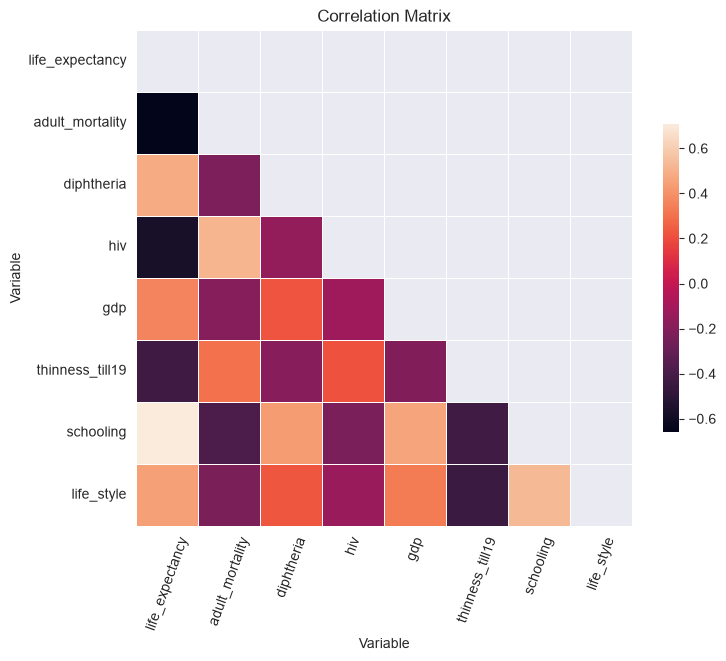

In [75]:
CorrMat(corr_map)

In [76]:
df_final.head()

,life_expectancy,adult_mortality,diphtheria,hiv,gdp,thinness_till19,schooling,life_style
1,59.9,271.0,62.0,0.1,612.696514,17.5,10.0,0.186
3,59.5,272.0,67.0,0.1,669.959000,17.9,9.8,0.176
4,59.2,275.0,68.0,0.1,63.537231,18.2,9.5,0.172
5,58.8,279.0,66.0,0.1,553.328940,18.4,9.2,0.167
6,58.6,281.0,63.0,0.1,445.893298,18.6,8.9,0.162


### Statistical Modeling

Statistical modeling involves building mathematical models that capture the relationships between variables in a dataset. These models are used to understand how variables are related and to support informed, data-driven decisions.

**Key Components of Statistical Modeling:**

**Variables and Data:** A collection of data that includes the dependent variable (the variable we want to explain or predict) and the independent variables (the factors that may influence the dependent variable).

**Mathematical Model:** A simplified representation of reality that expresses mathematical relationships between variables. Models can range from relatively simple approaches, such as Linear Regression, to more complex methods, such as Neural Networks.

**Parameter Estimation:** The process of fitting the model to the observed data. Methods such as **Ordinary Least Squares (OLS)** can be used to estimate the model parameters that best represent the relationship between the dependent and independent variables.

**Diagnostics and Validation:** The process of evaluating whether the model adequately represents the data. This includes analyzing residuals, checking model assumptions, evaluating statistical significance, and potentially modifying the model to improve its reliability and performance.


In [77]:
# target variable x pedicts variables
formula = 'life_expectancy ~ adult_mortality + diphtheria + hiv + gdp + thinness_till19 + schooling + life_style'

In [78]:
# Creates and fits the model
model_v1 = ols(formula, data=df_final).fit()

In [79]:
# Coefficient of Determination
print(f"R-squared: {model_v1.rsquared}")

R-squared: 0.7737705044839867


In [80]:
# Coefficient
print(f"Coeficientes:\n{model_v1.params}")

Coeficientes:
Intercept          51.016574
adult_mortality    -0.021286
diphtheria          0.079267
hiv                -0.484974
gdp                 0.000062
thinness_till19    -0.127453
schooling           1.289512
life_style          0.002567
dtype: float64


In [81]:
model_v1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     984.6
Date:                Sat, 19 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:47:44   Log-Likelihood:                -5852.1
No. Observations:                2023   AIC:                         1.172e+04
Df Residuals:                    2015   BIC:                         1.177e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          51.0166      0.667     76.474      0.000      49.708      52.325
adult_mortality    -0.0213      0.001    -22.068      0.000      -0.023      -0.019
diphtheria          0.0793      0.005     15.252      0.000       0.069       0.089
hiv                -0.4850      0.021    -22.928      0.000      -0.526      -0.443
gdp              6.181e-05   3.93e-05      1.574      0.116   -1.52e-05       0.000
thinness_till19    -0.1275      0.028     -4.546      0.000      -0.182      -0.072
schooling           1.2895      0.049     26.065      0.000       1.192       1.387
life_style          0.0026      0.001      4.451      0.000       0.001       0.004
==============================================================================
Omnibus:                      105.060   Durbin-Watson:                   0.675
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              194.134
Skew:                          -0.383   Prob(JB):                     6.99e-43
Kurtosis:                       4.310   Cond. No.                     2.53e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.53e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

> The `gdp` variable has a p-value greater than 0.05 and, therefore, is not statistically significant in explaining the target variable. For this reason, we will remove it from the model.

In [83]:
# Second version of the regression model
formula = 'life_expectancy ~ adult_mortality + diphtheria + hiv + thinness_till19 + schooling + life_style'

model_v2 = ols(formula, data=df_final).fit()

model_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     1147.
Date:                Sat, 19 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:50:47   Log-Likelihood:                -5853.3
No. Observations:                2023   AIC:                         1.172e+04
Df Residuals:                    2016   BIC:                         1.176e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          50.8445      0.658     77.233      0.000      49.553      52.136
adult_mortality    -0.0213      0.001    -22.094      0.000      -0.023      -0.019
diphtheria          0.0795      0.005     15.299      0.000       0.069       0.090
hiv                -0.4850      0.021    -22.922      0.000      -0.527      -0.444
thinness_till19    -0.1266      0.028     -4.515      0.000      -0.182      -0.072
schooling           1.3132      0.047     27.859      0.000       1.221       1.406
life_style          0.0027      0.001      4.671      0.000       0.002       0.004
==============================================================================
Omnibus:                      108.281   Durbin-Watson:                   0.676
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              199.828
Skew:                          -0.394   Prob(JB):                     4.05e-44
Kurtosis:                       4.323   Cond. No.                     2.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

> Note 2 above suggests that there may still be multicollinearity among the predictor variables. We could revisit our previous selection criterion and consider removing variables with correlations above 0.55, for example, instead of the 0.65 threshold used earlier. However, before doing that, we will standardize the data to place all variables on the same scale and then evaluate the results.

In [86]:
# Variables to be standardized
features = ['adult_mortality', 'diphtheria', 'hiv', 'thinness_till19', 'schooling', 'life_style']

In [87]:
# Standardization
scaler = StandardScaler()
scaler.fit(df_final[features])
scaled_features = scaler.transform(df_final[features])

In [88]:
# Creating a DataFrame with standardized data
scaled_features_df = pd.DataFrame(
    scaled_features,
    columns=features,
    index=df_final.index
)

scaled_features_df.head()

,adult_mortality,diphtheria,hiv,thinness_till19,schooling,life_style
1,0.784288,-1.070929,-0.337999,3.076510,-0.658477,-0.854062
3,0.792299,-0.830592,-0.337999,3.174831,-0.730539,-0.854109
4,0.816331,-0.782525,-0.337999,3.248572,-0.838631,-0.854128
5,0.848374,-0.878660,-0.337999,3.297732,-0.946724,-0.854152
6,0.864395,-1.022861,-0.337999,3.346893,-1.054817,-0.854176


In [89]:
# Third version of the regression model
model_v3 = sm.OLS(
    endog=df_final['life_expectancy'],
    exog=sm.add_constant(scaled_features_df.values)
).fit()

In [90]:
model_v3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     1147.
Date:                Sat, 19 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:56:53   Log-Likelihood:                -5853.3
No. Observations:                2023   AIC:                         1.172e+04
Df Residuals:                    2016   BIC:                         1.176e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.3059      0.097    702.041      0.000      68.115      68.497
x1            -2.6608      0.120    -22.094      0.000      -2.897      -2.425
x2             1.6541      0.108     15.299      0.000       1.442       1.866
x3            -2.6080      0.114    -22.922      0.000      -2.831      -2.385
x4            -0.5151      0.114     -4.515      0.000      -0.739      -0.291
x5             3.6447      0.131     27.859      0.000       3.388       3.901
x6             0.5602      0.120      4.671      0.000       0.325       0.795
==============================================================================
Omnibus:                      108.281   Durbin-Watson:                   0.676
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              199.828
Skew:                          -0.394   Prob(JB):                     4.05e-44
Kurtosis:                       4.323   Cond. No.                         2.56
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Interpretation of the Final Model

When communicating the results of this analysis to decision-makers, it is important to focus on key information that supports decision-making, simplify technical terminology, and highlight the practical implications of the findings. Below is an example of how the results of this analysis can be presented.

---

### Life Expectancy Analysis – Executive Summary

Our analysis used a statistical model to examine how different socioeconomic, health, and lifestyle factors are associated with life expectancy. The results provide valuable insights that can support public health strategies and resource allocation.

### Key Findings

**Model Performance**

The model explains approximately **77% of the observed variation in life expectancy**, indicating that the selected variables collectively provide substantial explanatory power for differences in life expectancy within the analyzed dataset.

**Impact of Health and Lifestyle Factors**

* **Adult Mortality and HIV:** Higher levels of adult mortality and HIV prevalence are significantly associated with lower life expectancy. These findings highlight the importance of prevention, treatment, and healthcare programs focused on reducing mortality and controlling HIV.

* **Education and Lifestyle:** Higher levels of education and healthier lifestyle indicators are positively associated with life expectancy. These results highlight the potential importance of education and health-promotion initiatives as components of broader public health strategies.

* **Vaccination and Nutrition:** The analysis also indicates that vaccination coverage, such as diphtheria immunization, and nutritional indicators, represented by lower levels of thinness among children and adolescents, are associated with higher life expectancy.

### Recommendations

* **Strengthen Prevention Programs:** Continue supporting prevention and treatment programs for critical health conditions such as HIV while improving vaccination coverage.

* **Promote Health Education:** Support educational initiatives that encourage healthier lifestyles and contribute to improved population health indicators.

* **Monitor and Evaluate:** Continuously monitor these health and socioeconomic indicators and evaluate public policies as new data becomes available.

### Conclusion

This analysis highlights the relationship between life expectancy and several health, education, nutrition, and lifestyle indicators. The findings provide evidence that can support data-driven discussions and help decision-makers identify areas that may deserve further investigation or policy attention.

It is important to note that the statistical model identifies **associations rather than causal relationships**. Therefore, additional analyses would be required before concluding that changes in any individual factor directly cause changes in life expectancy.

---
